In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!nvidia-smi

Sat Aug 15 15:05:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import os

BASE_PATH = "/content/drive/MyDrive/Thesis"
HAM_PATH = os.path.join(BASE_PATH, "HAM10000")
PAD_PATH = os.path.join(BASE_PATH, "PAD-UFES-20")

HAM_IMAGE_DIR = os.path.join(HAM_PATH, "images")
PAD_IMAGE_DIR = os.path.join(PAD_PATH, "images")

In [5]:
import pandas as pd

ham = pd.read_csv(os.path.join(HAM_PATH, "HAM10000_metadata.csv"))
print(ham.shape)
print(ham["dx"].value_counts())

(10015, 8)
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [6]:
HAM_CLASSES = ["akiec", "bcc", "mel", "nv"]

ham_4 = ham[ham["dx"].isin(HAM_CLASSES)].copy()

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

ham_4["label"] = ham_4["dx"].map({
    "akiec": "ACK",
    "bcc": "BCC",
    "mel": "MEL",
    "nv": "NEV"
})

print(ham_4["label"].value_counts())

label
NEV    6705
MEL    1113
BCC     514
ACK     327
Name: count, dtype: int64


In [7]:
HAIR_REMOVED_DIR = os.path.join(BASE_PATH, "HAM10000_hair_removed")

ham_4["image_path"] = ham_4["image_id"].apply(
    lambda x: os.path.join(HAIR_REMOVED_DIR, x + ".jpg")
)

ham_4["exists"] = ham_4["image_path"].apply(os.path.exists)
print(ham_4["exists"].value_counts())

exists
True    8659
Name: count, dtype: int64


In [8]:
pad = pd.read_csv(os.path.join(PAD_PATH, "metadata.csv"))
print(pad.shape)
print(pad["diagnostic"].value_counts())

(2298, 26)
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


In [9]:
PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

print(pad_4["label"].value_counts())

label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [10]:
pad_4["image_path"] = pad_4["img_id"].apply(
    lambda x: os.path.join(PAD_IMAGE_DIR, x)
)

pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)
print(pad_4["exists"].value_counts())

exists
True    1871
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(ham_4, groups=ham_4["lesion_id"])
)

train_df = ham_4.iloc[train_idx].copy()
val_df = ham_4.iloc[val_idx].copy()

print("Training:", len(train_df))
print("Validation:", len(val_df))

Training: 6932
Validation: 1727


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (250, 250)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True,
    brightness_range=(0.7, 1.3),
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator()

In [13]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=42
)

Found 6932 validated image filenames belonging to 4 classes.


In [14]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

Found 1727 validated image filenames belonging to 4 classes.


In [15]:
x_batch, y_batch = next(train_generator)
print(x_batch.shape)
print(y_batch.shape)

(16, 250, 250, 3)
(16, 4)


In [16]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(250, 250, 3)
)

base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)

output = Dense(
    4,
    activation="softmax",
    dtype="float32"
)(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250, 250,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 250, 250,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 250, 250,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 250, 250,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 251, 251,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 125, 125,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 125, 125,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 125, 125,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 125, 125,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 125, 125,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 125, 125,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 125, 125,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 125, 125,  │        960 │ block1a_se_excit

 Total params: 10,789,683 (41.16 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [18]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Thesis/hair_aug_best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [20]:
history_hair_aug = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 2975s 7s/step - accuracy: 0.7715 - loss: 0.6049 - val_accuracy: 0.7892 - val_loss: 0.5363 - learning_rate: 0.0010
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 153s 353ms/step - accuracy: 0.7962 - loss: 0.5302 - val_accuracy: 0.8049 - val_loss: 0.4976 - learning_rate: 0.0010
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 153s 351ms/step - accuracy: 0.8044 - loss: 0.5061 - val_accuracy: 0.8124 - val_loss: 0.4453 - learning_rate: 0.0010
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 154s 356ms/step - accuracy: 0.8055 - loss: 0.5035 - val_accuracy: 0.8188 - val_loss: 0.4520 - learning_rate: 0.0010
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 153s 352ms/step - accuracy: 0.8128 - loss: 0.4970 - val_accuracy: 0.8060 - val_loss: 0.5035 - learning_rate: 0.0010
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 149s 344ms/step - accuracy: 0.8106 - loss: 0.4831 - val_accuracy: 0.8060 - val_loss: 0.4931 - learning_rate: 5.0000e-04
Epoch 7/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 150s 345ms/step - accu

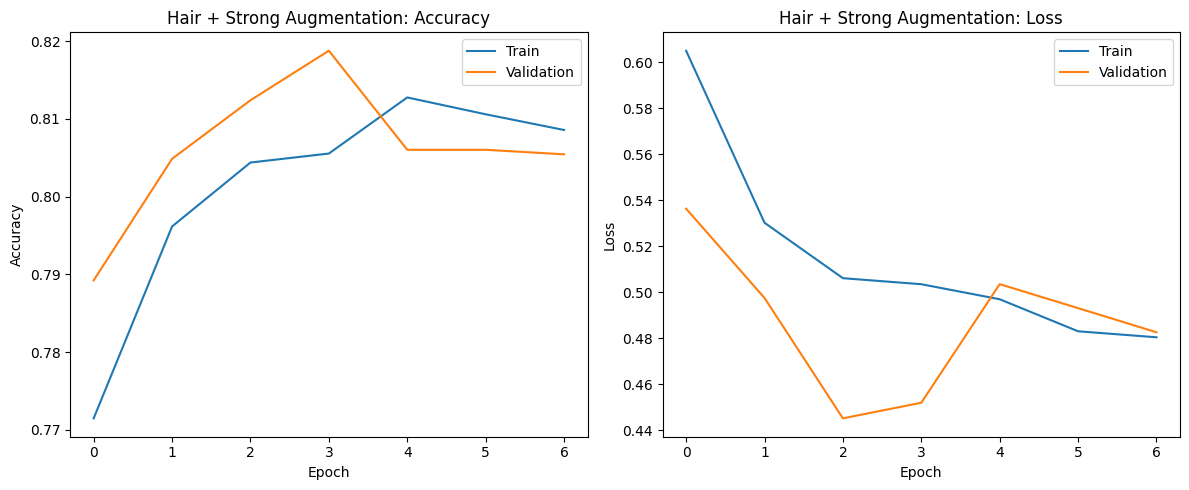

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_hair_aug.history["accuracy"], label="Train")
plt.plot(history_hair_aug.history["val_accuracy"], label="Validation")
plt.title("Hair + Strong Augmentation: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hair_aug.history["loss"], label="Train")
plt.plot(history_hair_aug.history["val_loss"], label="Validation")
plt.title("Hair + Strong Augmentation: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
from tensorflow.keras.models import load_model

hair_aug_model = load_model(
    "/content/drive/MyDrive/Thesis/hair_aug_best_model.keras"
)

print("Hair+Aug best model loaded.")

Hair+Aug best model loaded.


In [24]:
pad_datagen = ImageDataGenerator()

pad_generator = pad_datagen.flow_from_dataframe(
    dataframe=pad_4,
    x_col="image_path",
    y_col="label",
    target_size=(250, 250),
    batch_size=16,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("PAD samples:", pad_generator.samples)

Found 1871 validated image filenames belonging to 4 classes.
PAD samples: 1871


In [25]:
pad_loss_hair_aug, pad_accuracy_hair_aug = hair_aug_model.evaluate(
    pad_generator,
    verbose=1
)

print("Hair+Aug PAD Accuracy:", pad_accuracy_hair_aug)
print("Hair+Aug PAD Loss:", pad_loss_hair_aug)

117/117 ━━━━━━━━━━━━━━━━━━━━ 979s 8s/step - accuracy: 0.3079 - loss: 1.8647
Hair+Aug PAD Accuracy: 0.3078567683696747
Hair+Aug PAD Loss: 1.864701747894287


In [26]:
import numpy as np

pred_probs_hair_aug = hair_aug_model.predict(pad_generator, verbose=1)
pred_classes_hair_aug = np.argmax(pred_probs_hair_aug, axis=1)
true_classes_hair_aug = pad_generator.classes

117/117 ━━━━━━━━━━━━━━━━━━━━ 116s 898ms/step


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

hair_aug_accuracy = accuracy_score(true_classes_hair_aug, pred_classes_hair_aug)
hair_aug_precision = precision_score(true_classes_hair_aug, pred_classes_hair_aug, average="macro", zero_division=0)
hair_aug_recall = recall_score(true_classes_hair_aug, pred_classes_hair_aug, average="macro", zero_division=0)
hair_aug_f1 = f1_score(true_classes_hair_aug, pred_classes_hair_aug, average="macro", zero_division=0)

print("Accuracy :", hair_aug_accuracy)
print("Precision:", hair_aug_precision)
print("Recall   :", hair_aug_recall)
print("F1 Score :", hair_aug_f1)

Accuracy : 0.307856761090326
Precision: 0.36039881953362773
Recall   : 0.38220129837341227
F1 Score : 0.2497280145160781


In [28]:
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import roc_auc_score

true_onehot_hair_aug = to_categorical(true_classes_hair_aug, num_classes=4)

auc_hair_aug = roc_auc_score(
    true_onehot_hair_aug,
    pred_probs_hair_aug,
    multi_class="ovr",
    average="macro"
)

print("Hair+Aug Macro AUC:", auc_hair_aug)

Hair+Aug Macro AUC: 0.7158020108751602


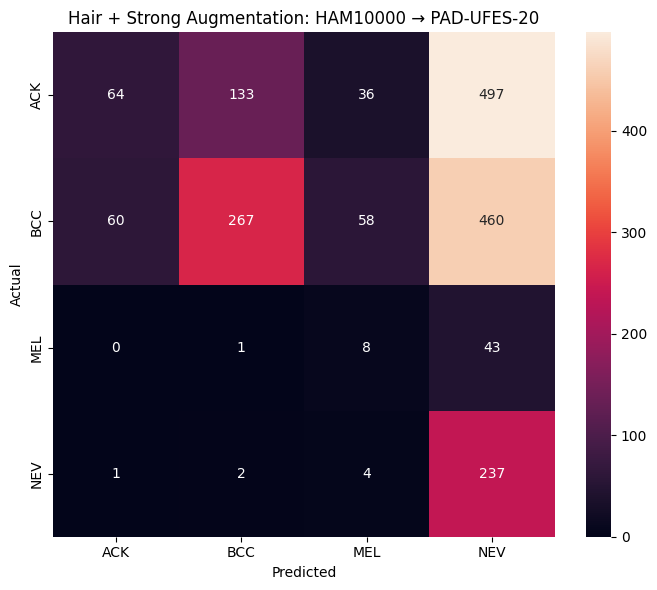

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_hair_aug = confusion_matrix(true_classes_hair_aug, pred_classes_hair_aug)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_hair_aug, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hair + Strong Augmentation: HAM10000 → PAD-UFES-20")
plt.tight_layout()
plt.show()